# Extract Features from GAVD Datasets

## 1.  Setup

In [1]:
# Configure matplotlib FIRST before any other imports
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt

# Verify matplotlib backend
print(f"Matplotlib backend: {matplotlib.get_backend()}")

# Enable interactive mode
plt.ion()

Matplotlib backend: module://matplotlib_inline.backend_inline


In [2]:
# Suppress TensorFlow and MediaPipe logs
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['GLOG_minloglevel'] = '3'

import sys
import string
import contextlib
import pandas as pd
import seaborn as sns
import numpy as np
from pathlib import Path
from collections import defaultdict

# Setup paths
project_root = Path.cwd().parent.parent
video_base_path = project_root / "data" / "youtube"
data_root = project_root / "experiments" / "exp4" / "data"

sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print(f"Data root: {data_root}")
print(f"Video path: {video_base_path}")

Project root: /Users/alexmui/dev/alexpose
Data root: /Users/alexmui/dev/alexpose/experiments/exp4/data
Video path: /Users/alexmui/dev/alexpose/data/youtube


In [3]:
from ambient.gavd import GAVDDataLoader
from ambient.pose.keypoint_extractor import SequenceKeypointExtractor
from ambient.pose.joint_angles import get_joint_angles


print("✓ Imports successful")

✓ Imports successful


## 2. Explore Training Dataset

In [4]:
data_root

PosixPath('/Users/alexmui/dev/alexpose/experiments/exp4/data')

In [5]:
# Get condition directories
condition_paths = [
    p for p in data_root.iterdir() 
    if p.is_dir() and p.name[0] in string.ascii_letters
]

len(condition_paths)

5

In [6]:

print(f"Found {len(condition_paths)} conditions:\n")
for path in sorted(condition_paths):
    csv_files = list(path.glob("*.csv"))
    print(f"  {path.name:15s}: {len(csv_files)} CSV files")

Found 5 conditions:

  cerebralpalsy  : 15 CSV files
  myopathic      : 20 CSV files
  normal         : 12 CSV files
  parkinsons     : 9 CSV files
  stroke         : 12 CSV files


## 3.  Extract Keypoints from One Gait (CSV) Sequence

In [7]:
condition_paths

[PosixPath('/Users/alexmui/dev/alexpose/experiments/exp4/data/stroke'),
 PosixPath('/Users/alexmui/dev/alexpose/experiments/exp4/data/myopathic'),
 PosixPath('/Users/alexmui/dev/alexpose/experiments/exp4/data/parkinsons'),
 PosixPath('/Users/alexmui/dev/alexpose/experiments/exp4/data/normal'),
 PosixPath('/Users/alexmui/dev/alexpose/experiments/exp4/data/cerebralpalsy')]

In [8]:
normal_path = condition_paths[3]
stroke_path = condition_paths[0]
parkinsons_path = condition_paths[2]
myopathic_path = condition_paths[1]
cerebralpalsy_path = condition_paths[4]

normal_path, stroke_path, parkinsons_path, myopathic_path, cerebralpalsy_path

(PosixPath('/Users/alexmui/dev/alexpose/experiments/exp4/data/normal'),
 PosixPath('/Users/alexmui/dev/alexpose/experiments/exp4/data/stroke'),
 PosixPath('/Users/alexmui/dev/alexpose/experiments/exp4/data/parkinsons'),
 PosixPath('/Users/alexmui/dev/alexpose/experiments/exp4/data/myopathic'),
 PosixPath('/Users/alexmui/dev/alexpose/experiments/exp4/data/cerebralpalsy'))

In [9]:
# Let's get the first CSV from the normal_path
normal_csv = list(normal_path.glob("*.csv"))[11]
stroke_csv = list(stroke_path.glob("*.csv"))[0]
parkinsons_csv = list(parkinsons_path.glob("*.csv"))[3]
myopathic_csv = list(myopathic_path.glob("*.csv"))[1]
cerebralpalsy_csv = list(cerebralpalsy_path.glob("*.csv"))[1]
normal_csv, stroke_csv, parkinsons_csv

(PosixPath('/Users/alexmui/dev/alexpose/experiments/exp4/data/normal/cljo32213001u3n6lel97up5f.csv'),
 PosixPath('/Users/alexmui/dev/alexpose/experiments/exp4/data/stroke/cljvvsucg00043n6l4evgn7q4.csv'),
 PosixPath('/Users/alexmui/dev/alexpose/experiments/exp4/data/parkinsons/cljnz5sb1000o3n6lntosswwz.csv'))

In [10]:
gavd_loader = GAVDDataLoader()

normal_df = gavd_loader.load_gavd_data(normal_csv)
stroke_df = gavd_loader.load_gavd_data(stroke_csv)
parkinsons_df = gavd_loader.load_gavd_data(parkinsons_csv)
myopathic_df = gavd_loader.load_gavd_data(myopathic_csv)
cerebralpalsy_df = gavd_loader.load_gavd_data(cerebralpalsy_csv)


normal_df.shape, stroke_df.shape, parkinsons_df.shape, myopathic_df.shape, cerebralpalsy_df.shape

((70, 12), (166, 12), (81, 12), (153, 12), (152, 12))

In [11]:
normal_sid = normal_df.iloc[0]["seq"]
stroke_sid = stroke_df.iloc[0]["seq"]
parkinsons_sid = parkinsons_df.iloc[0]["seq"]
myopathic_sid = myopathic_df.iloc[0]["seq"]
cerebralpalsy_sid = cerebralpalsy_df.iloc[0]["seq"]

normal_sid, stroke_sid, parkinsons_sid, myopathic_sid, cerebralpalsy_sid

('cljo32213001u3n6lel97up5f',
 'cljvvsucg00043n6l4evgn7q4',
 'cljnz5sb1000o3n6lntosswwz',
 'cljo83yl800513n6lfglf5jn8',
 'cljarbn1y00cg3n6l1u4i0d5l')

In [12]:
video_base_path

PosixPath('/Users/alexmui/dev/alexpose/data/youtube')

In [13]:
extractor = SequenceKeypointExtractor()
normal_keypoints_array = extractor.extract_from_sequence(
    sequence_data=normal_df,
    video_base_path=video_base_path,
    filter_empty=True,    # remove frames with <25 keypoints
    min_keypoints=25,     # at least 25 of the 33 keypoints to be valid
    verbose=True
)
stroke_keypoints_array = extractor.extract_from_sequence(
    sequence_data=stroke_df,
    video_base_path=video_base_path,
    filter_empty=True,    # remove frames with <25 keypoints
    min_keypoints=25,     # at least 25 of the 33 keypoints to be valid
    verbose=True
)
parkinsons_keypoints_array = extractor.extract_from_sequence(
    sequence_data=parkinsons_df,
    video_base_path=video_base_path, 
    filter_empty=True,    # remove frames with <25 keypoints
    min_keypoints=25,     # at least 25 of the 33 keypoints to be valid
    verbose=True
)
myopathic_keypoints_array = extractor.extract_from_sequence(
    sequence_data=myopathic_df,
    video_base_path=video_base_path,
    filter_empty=True,    # remove frames with <25 keypoints
    min_keypoints=25,     # at least 25 of the 33 keypoints to be valid
    verbose=True
)
cerebralpalsy_keypoints_array = extractor.extract_from_sequence(
    sequence_data=cerebralpalsy_df,
    video_base_path=video_base_path,
    filter_empty=True,    # remove frames with <25 keypoints
    min_keypoints=25,     # at least 25 of the 33 keypoints to be valid
    verbose=True
)


I0000 00:00:1769229933.145481 7386716 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1769229933.215898 7386717 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769229933.241839 7386717 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
2026-01-23 20:45:33.242 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:434 - Processing sequence: cljo32213001u3n6lel97up5f (70 frames)


	frame 561 (1/70)


W0000 00:00:1769229933.572216 7386722 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


	frame 571 (11/70)
	frame 581 (21/70)
	frame 591 (31/70)
	frame 601 (41/70)
	frame 611 (51/70)
	frame 621 (61/70)


2026-01-23 20:45:47.609 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:459 - Processed 70/70 frames successfully
2026-01-23 20:45:47.610 | INFO     | ambient.pose.keypoint_extractor:_filter_keypoints:547 - Filtered to 70/70 frames (min 25 keypoints, removed 0)
2026-01-23 20:45:47.611 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:434 - Processing sequence: cljvvsucg00043n6l4evgn7q4 (166 frames)


...

2026-01-23 20:47:42.446 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:459 - Processed 153/153 frames successfully
2026-01-23 20:47:42.446 | INFO     | ambient.pose.keypoint_extractor:_filter_keypoints:547 - Filtered to 143/153 frames (min 25 keypoints, removed 10)
2026-01-23 20:47:42.448 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:434 - Processing sequence: cljarbn1y00cg3n6l1u4i0d5l (152 frames)


	frame 2026 (1/152)
	frame 2036 (11/152)
	frame 2046 (21/152)
	frame 2056 (31/152)


I0000 00:00:1769230071.445125 7408694 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1769230071.499546 7408695 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769230071.510373 7408695 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


	frame 2066 (41/152)
	frame 2076 (51/152)
	frame 2086 (61/152)
	frame 2096 (71/152)
	frame 2106 (81/152)
	frame 2116 (91/152)
	frame 2126 (101/152)
	frame 2136 (111/152)
	frame 2146 (121/152)
	frame 2156 (131/152)
	frame 2166 (141/152)
	frame 2176 (151/152)


2026-01-23 20:48:27.110 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:459 - Processed 152/152 frames successfully
2026-01-23 20:48:27.110 | INFO     | ambient.pose.keypoint_extractor:_filter_keypoints:547 - Filtered to 152/152 frames (min 25 keypoints, removed 0)


In [15]:
len(normal_keypoints_array), \
len(stroke_keypoints_array), \
len(parkinsons_keypoints_array), \
len(cerebralpalsy_keypoints_array), \
len(myopathic_keypoints_array)

(70, 166, 81, 152, 143)

In [17]:
len(normal_keypoints_array[9].keypoints), \
len(stroke_keypoints_array[0].keypoints), \
len(parkinsons_keypoints_array[0].keypoints), \
len(myopathic_keypoints_array[0].keypoints), \
len(cerebralpalsy_keypoints_array[0].keypoints) 

(33, 33, 33, 33, 33)

In [19]:
# let's look at the first keypoint at frame 0
normal_keypoints_array[0].keypoints[32]

Keypoint(id=32, name='RIGHT_FOOT_INDEX', x=163.68678158521652, y=298.0490827560425, z=0.11986704170703888, confidence=0.9579150676727295, visibility=0.9579150676727295, presence=0.9897558093070984, x_normalized=0.33134976029396057, y_normalized=0.8279141187667847)

In [20]:
from pprint import pprint

print(vars(normal_keypoints_array[0].keypoints[0]))

{'id': 0, 'name': 'NOSE', 'x': 170.82813584804535, 'y': 74.74539756774902, 'z': -0.4195651710033417, 'confidence': 0.9998936653137207, 'visibility': 0.9998936653137207, 'presence': 0.9991220831871033, 'x_normalized': 0.34580594301223755, 'y_normalized': 0.2076261043548584}


## 4.  Calculate Frame-by-Frame Joint Angles

In [39]:
normal_joint_angles = get_joint_angles(
    keypoints_array=normal_keypoints_array,
    keypoint_format="BLAZEPOSE_33",
    fps=30.0,
    confidence_threshold=0.3,
    sequence_id=normal_sid
)
stroke_joint_angles = get_joint_angles(
    keypoints_array=stroke_keypoints_array,
    keypoint_format="BLAZEPOSE_33",
    fps=30.0,
    confidence_threshold=0.3,
    sequence_id=stroke_sid
)
parkinsons_joint_angles = get_joint_angles(
    keypoints_array=parkinsons_keypoints_array,
    keypoint_format="BLAZEPOSE_33",
    fps=30.0,
    confidence_threshold=0.3,
    sequence_id=parkinsons_sid
)
myopathic_joint_angles = get_joint_angles(
    keypoints_array=myopathic_keypoints_array,
    keypoint_format="BLAZEPOSE_33",
    fps=30.0,
    confidence_threshold=0.3,
    sequence_id=myopathic_sid
)
cerebralpalsy_joint_angles = get_joint_angles(
    keypoints_array=cerebralpalsy_keypoints_array,
    keypoint_format="BLAZEPOSE_33",
    fps=30.0,
    confidence_threshold=0.3,
    sequence_id=cerebralpalsy_sid
)
# let's see which joint angles are calculated for Frame 0 (same for all other frames)
print(normal_joint_angles.frames[0].angles.keys())

dict_keys(['left_hip', 'left_knee', 'right_hip', 'right_knee', 'left_ankle', 'right_ankle'])


In [26]:
print("Normal Gait: Left Hip")
normal_joint_angles.get_statistics("left_hip")

Normal Gait: Left Hip


{'mean': 173.21557224921955,
 'std': 5.450965749476707,
 'min': 161.8259557780825,
 'max': 179.82970184214903,
 'range': 18.003746064066547,
 'valid_count': 70}

In [27]:
print("Stroke Gait: Left Hip")
stroke_joint_angles.get_statistics("left_hip")


Stroke Gait: Left Hip


{'mean': 171.3842251916409,
 'std': 2.2520250265981283,
 'min': 166.88114848569077,
 'max': 176.23415465679045,
 'range': 9.353006171099679,
 'valid_count': 166}

In [28]:
print("Parkinsons Gait: Left Hip")
parkinsons_joint_angles.get_statistics("left_hip")

Parkinsons Gait: Left Hip


{'mean': 172.43373954137832,
 'std': 3.187904924441527,
 'min': 163.13745808388595,
 'max': 178.2780761383189,
 'range': 15.140618054432963,
 'valid_count': 81}

In [40]:
print("Myopathic Gait: Left Hip")
myopathic_joint_angles.get_statistics("left_hip")


Myopathic Gait: Left Hip


{'mean': 168.73226368399423,
 'std': 8.770830008716247,
 'min': 102.41334747622302,
 'max': 179.96045931209068,
 'range': 77.54711183586765,
 'valid_count': 143}

In [31]:
print("Parkinson's Gait: Left Hip")
parkinsons_joint_angles.get_statistics("left_hip")


Parkinson's Gait: Left Hip


{'mean': 172.43373954137832,
 'std': 3.187904924441527,
 'min': 163.13745808388595,
 'max': 178.2780761383189,
 'range': 15.140618054432963,
 'valid_count': 81}

Let's visualize the joint angle changes over a gait sequence

In [33]:
import matplotlib.pyplot as plt

def plot_joint_angles_statistics(name, joint_angles):

    print(f"\nVisualizing joint angles for {name}...")
    print(f"Number of frames with joint angles: {len(joint_angles.frames)}")

    if len(joint_angles.frames) > 0 and len(joint_angles.frames[0].angles) > 0:
        joints = ['left_hip', 'left_knee', 'left_ankle', 'right_hip', 'right_knee', 'right_ankle']
        
        # Create the figure
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        fig.suptitle(f"{name} Joint Angles Over Time", fontsize=18, fontweight='bold')
        
        for idx, joint_name in enumerate(joints):
            row = idx // 3
            col = idx % 3
            ax = axes[row, col]
            
            try:
                # Get angle data
                angles = joint_angles.get_joint_angle_series(joint_name)
                stats = joint_angles.get_statistics(joint_name)
                
                # Check if we have valid data
                if stats['valid_count'] > 0 and not np.isnan(stats['mean']):
                    # Filter out NaN values
                    valid_mask = ~np.isnan(angles)
                    valid_frames = np.where(valid_mask)[0]
                    valid_angles = angles[valid_mask]
                    
                    if len(valid_angles) > 0:
                        # Plot the angle series
                        ax.plot(valid_frames, valid_angles, 'b-', linewidth=2, alpha=0.7, label='Angle')
                        
                        # Add mean line
                        ax.axhline(y=stats['mean'], color='red', linestyle='--', 
                                linewidth=2, alpha=0.8, label=f"Mean: {stats['mean']:.1f}°")
                        
                        # Add shaded region for std
                        ax.axhspan(stats['mean'] - stats['std'], stats['mean'] + stats['std'], 
                                alpha=0.2, color='red', label=f"±1 SD")
                        
                        # Formatting
                        ax.set_title(joint_name.replace('_', ' ').title(), 
                                    fontsize=13, fontweight='bold', pad=10)
                        ax.set_xlabel('Frame Number', fontsize=11)
                        ax.set_ylabel('Angle (degrees)', fontsize=11)
                        ax.legend(loc='best', fontsize=9, framealpha=0.9)
                        ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
                        
                        # Set reasonable y-axis limits
                        y_margin = (stats['max'] - stats['min']) * 0.1
                        ax.set_ylim(stats['min'] - y_margin, stats['max'] + y_margin)
                    else:
                        ax.text(0.5, 0.5, 'No valid angle data', 
                            ha='center', va='center', transform=ax.transAxes, 
                            fontsize=12, color='gray')
                        ax.set_title(joint_name.replace('_', ' ').title())
                else:
                    ax.text(0.5, 0.5, 'Insufficient data', 
                        ha='center', va='center', transform=ax.transAxes, 
                        fontsize=12, color='gray')
                    ax.set_title(joint_name.replace('_', ' ').title())
                    
            except Exception as e:
                ax.text(0.5, 0.5, f'Error: {str(e)[:40]}', 
                    ha='center', va='center', transform=ax.transAxes, 
                    fontsize=10, color='red', wrap=True)
                ax.set_title(joint_name.replace('_', ' ').title())
                print(f"Error plotting {joint_name}: {e}")
        
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
        
        # Print statistics table
        print("\n" + "="*70)
        print("Joint Angle Statistics")
        print("="*70)
        print(f"{'Joint':<15} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'Range':>8}")
        print("-"*70)
        
        for joint_name in joints:
            try:
                stats = joint_angles.get_statistics(joint_name)
                if stats['valid_count'] > 0:
                    print(f"{joint_name:<15} {stats['mean']:>8.1f}° {stats['std']:>7.1f}° "
                        f"{stats['min']:>7.1f}° {stats['max']:>7.1f}° {stats['range']:>7.1f}°")
                else:
                    print(f"{joint_name:<15} {'No data':>8}")
            except Exception as e:
                print(f"{joint_name:<15} Error: {e}")
        print("="*70 + "\n")
        
    else:
        print("\n⚠️  WARNING: No joint angles computed!")
        print(f"   Total frames: {len(joint_angles.frames)}")
        if len(joint_angles.frames) > 0:
            print(f"   Angles in first frame: {len(joint_angles.frames[0].angles)}")
            print(f"   Available joints: {list(joint_angles.frames[0].angles.keys())}")
        print("   Check if keypoints were extracted successfully.\n")


Visualizing joint angles for Normal Gait...
Number of frames with joint angles: 70


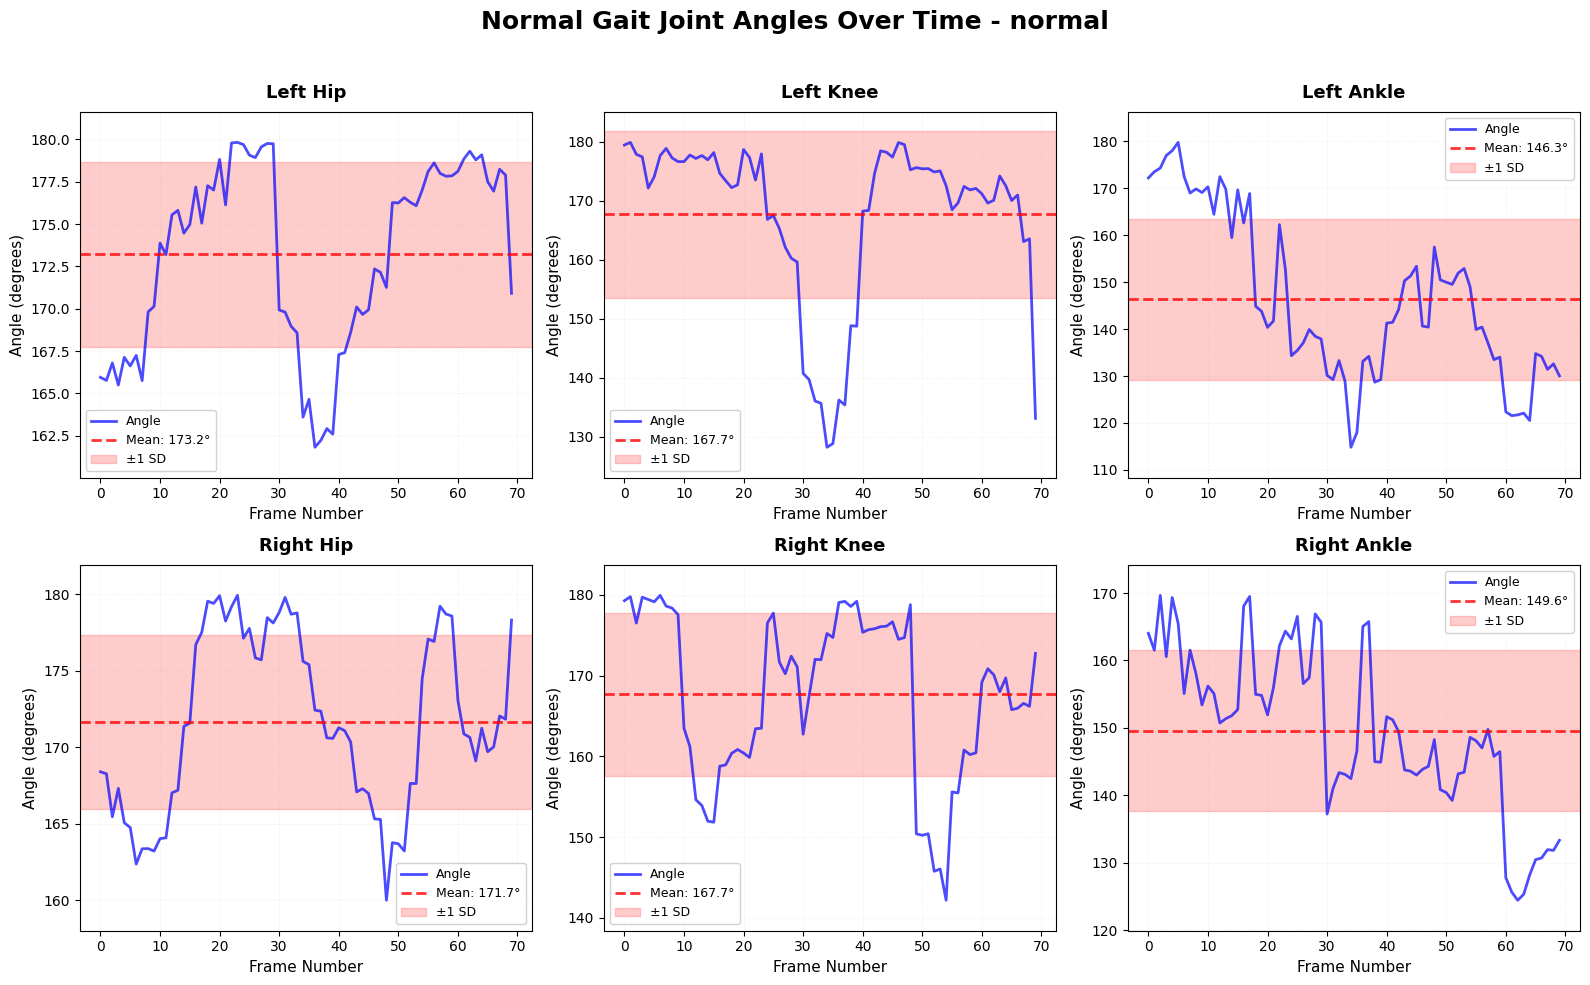


Joint Angle Statistics
Joint               Mean      Std      Min      Max    Range
----------------------------------------------------------------------
left_hip           173.2°     5.5°   161.8°   179.8°    18.0°
left_knee          167.7°    14.1°   128.2°   179.9°    51.7°
left_ankle         146.3°    17.2°   114.8°   179.8°    64.9°
right_hip          171.7°     5.7°   160.0°   179.9°    19.9°
right_knee         167.7°    10.1°   142.2°   179.9°    37.8°
right_ankle        149.6°    12.0°   124.5°   169.6°    45.2°



In [34]:
plot_joint_angles_statistics("Normal Gait", normal_joint_angles)


Visualizing joint angles for Stroke Gait...
Number of frames with joint angles: 166


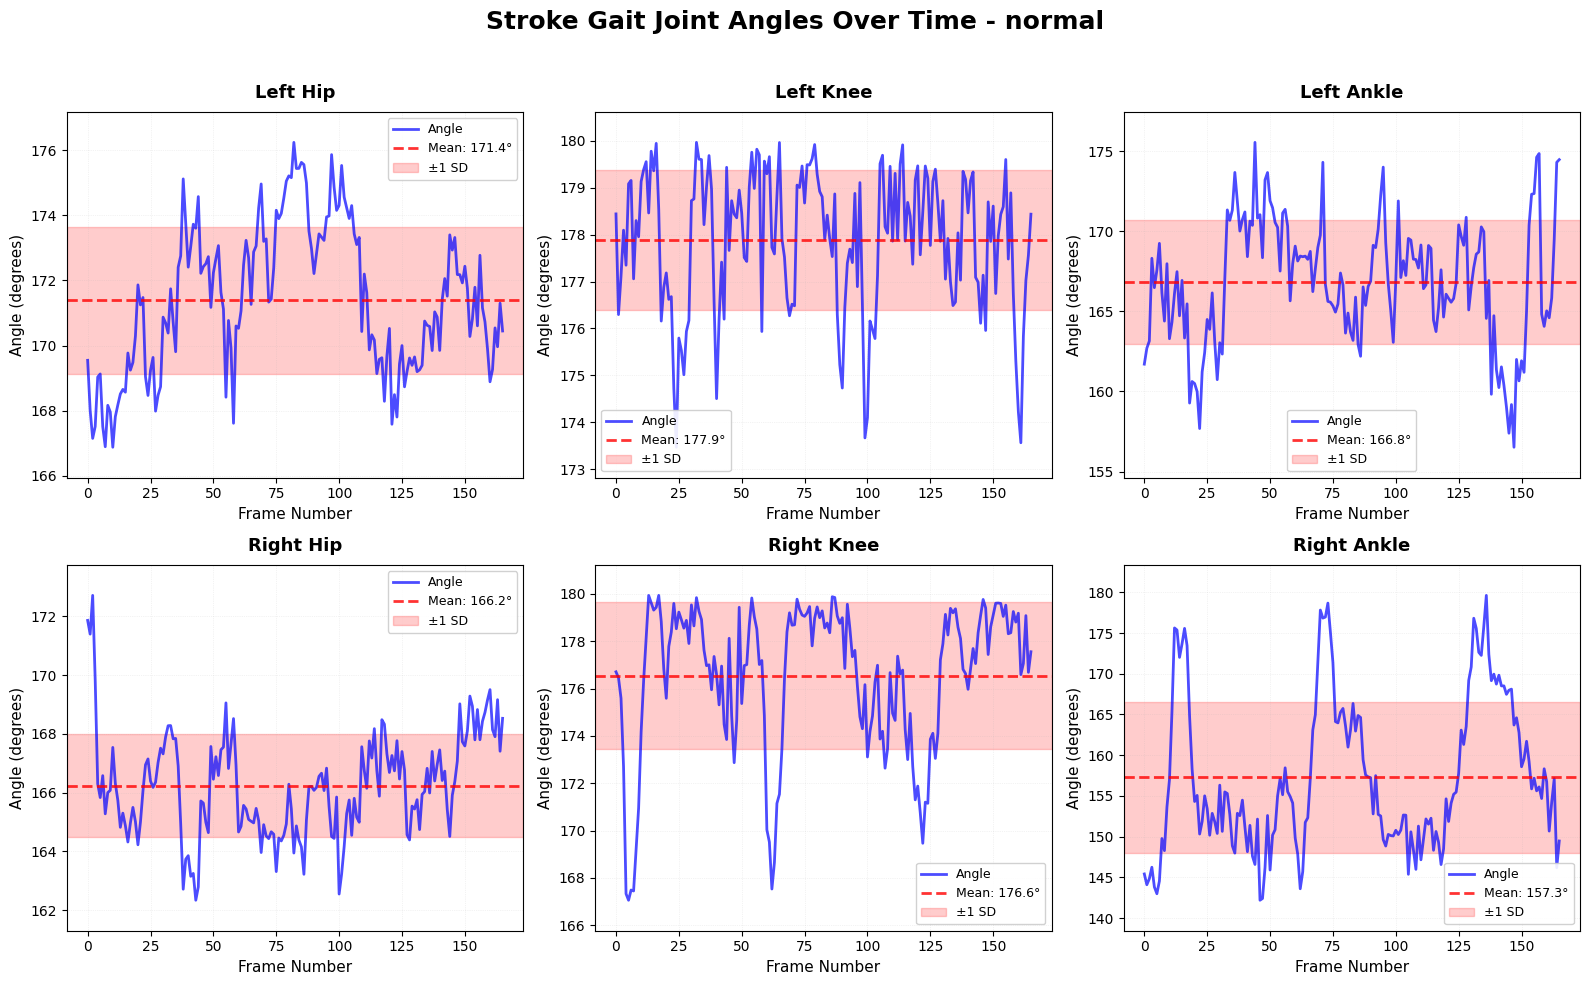


Joint Angle Statistics
Joint               Mean      Std      Min      Max    Range
----------------------------------------------------------------------
left_hip           171.4°     2.3°   166.9°   176.2°     9.4°
left_knee          177.9°     1.5°   173.5°   180.0°     6.5°
left_ankle         166.8°     3.9°   156.5°   175.5°    19.0°
right_hip          166.2°     1.8°   162.3°   172.7°    10.4°
right_knee         176.6°     3.1°   167.1°   179.9°    12.9°
right_ankle        157.3°     9.3°   142.2°   179.6°    37.4°



In [35]:
plot_joint_angles_statistics("Stroke Gait", stroke_joint_angles)


Visualizing joint angles for Parkinsons Gait...
Number of frames with joint angles: 81


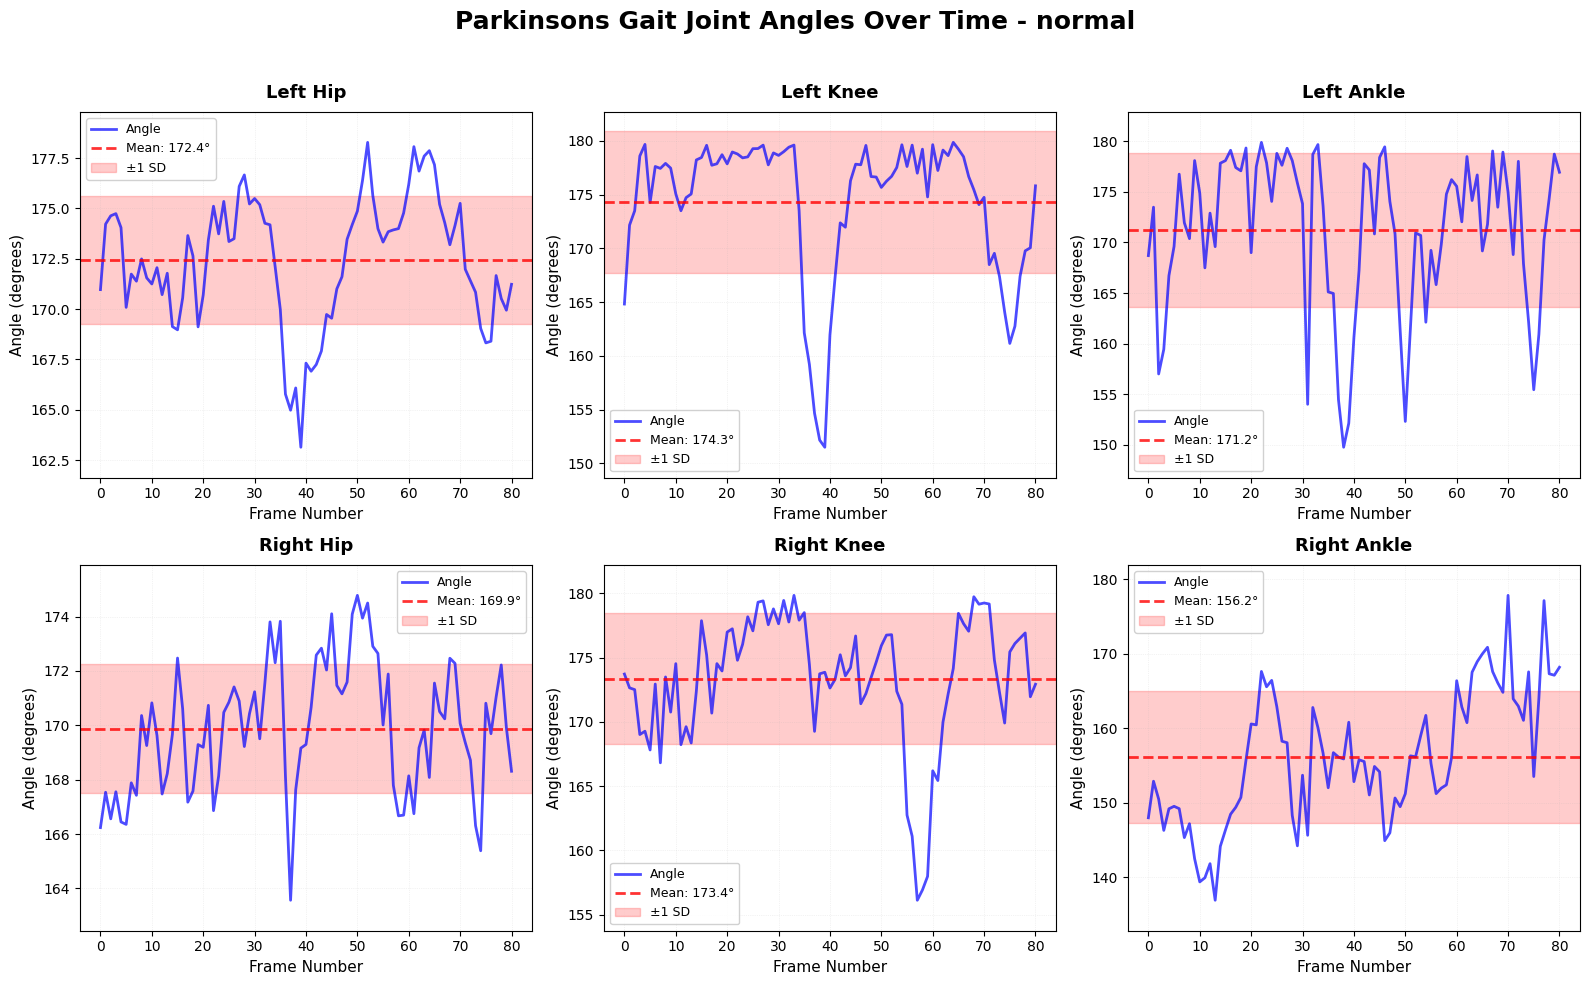


Joint Angle Statistics
Joint               Mean      Std      Min      Max    Range
----------------------------------------------------------------------
left_hip           172.4°     3.2°   163.1°   178.3°    15.1°
left_knee          174.3°     6.6°   151.5°   179.9°    28.4°
left_ankle         171.2°     7.6°   149.8°   179.9°    30.1°
right_hip          169.9°     2.4°   163.6°   174.8°    11.2°
right_knee         173.4°     5.1°   156.1°   179.9°    23.7°
right_ankle        156.2°     8.8°   136.9°   177.8°    40.9°



In [36]:
plot_joint_angles_statistics("Parkinsons Gait", parkinsons_joint_angles)


Visualizing joint angles for Myopathic Gait...
Number of frames with joint angles: 143


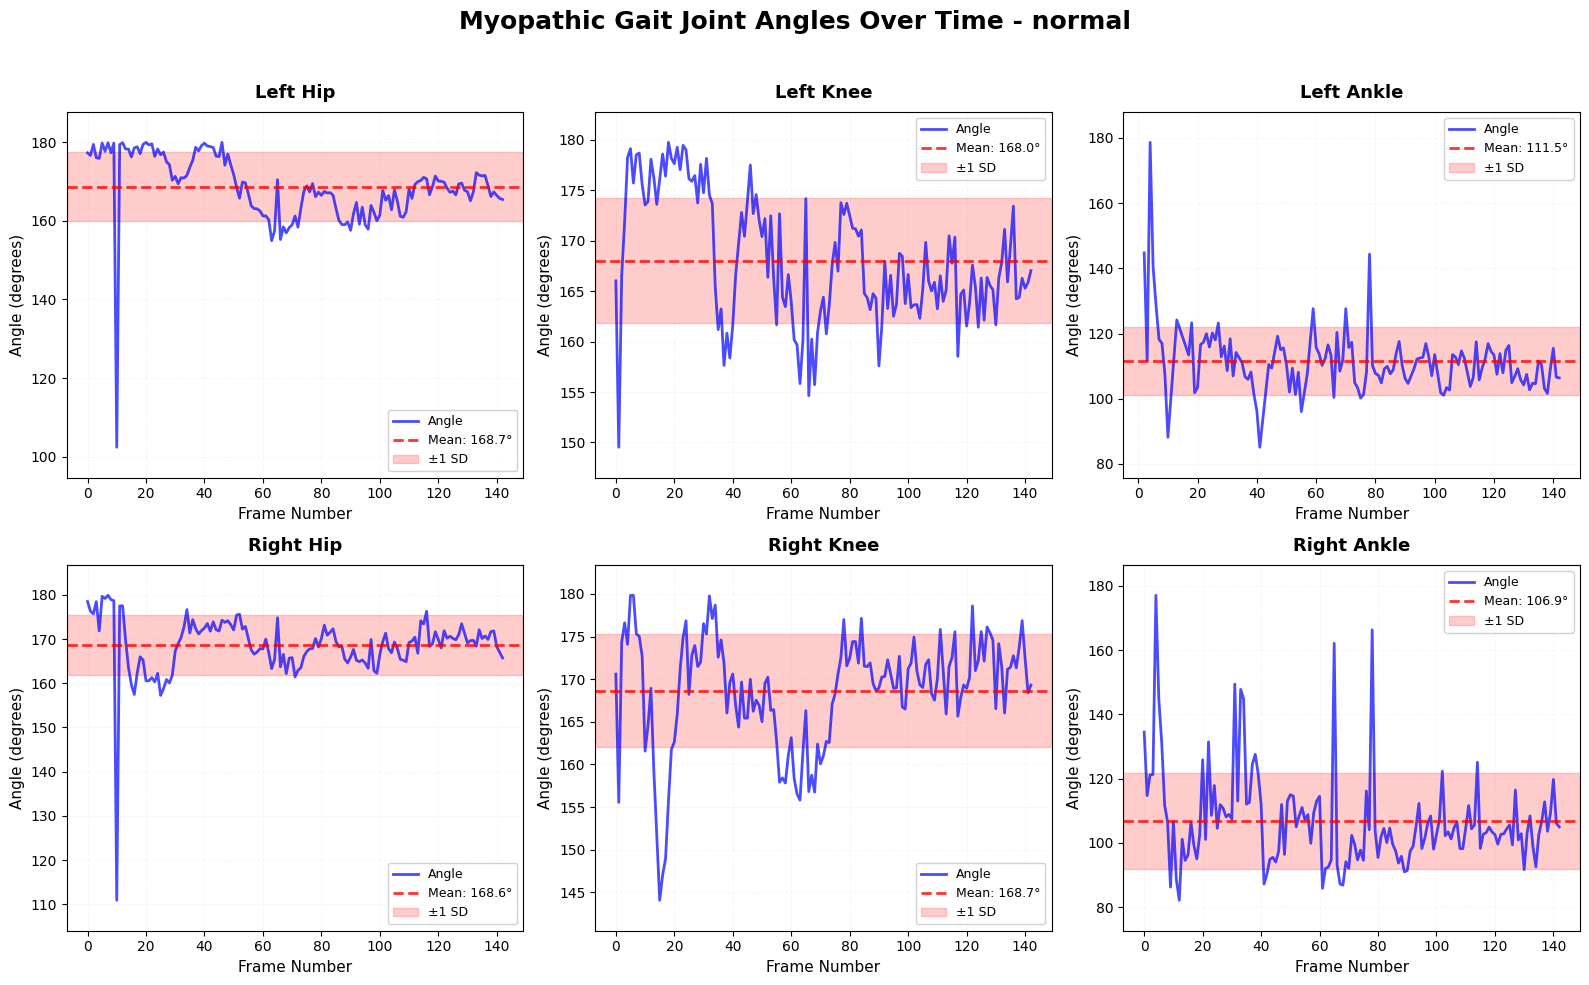


Joint Angle Statistics
Joint               Mean      Std      Min      Max    Range
----------------------------------------------------------------------
left_hip           168.7°     8.8°   102.4°   180.0°    77.5°
left_knee          168.0°     6.2°   149.5°   179.8°    30.2°
left_ankle         111.5°    10.4°    85.1°   178.6°    93.5°
right_hip          168.6°     6.8°   110.9°   179.9°    69.0°
right_knee         168.7°     6.6°   144.1°   179.8°    35.7°
right_ankle        106.9°    15.0°    82.2°   177.1°    94.9°



In [41]:
plot_joint_angles_statistics("Myopathic Gait", myopathic_joint_angles)


Visualizing joint angles for Cerebral Palsy Gait...
Number of frames with joint angles: 152


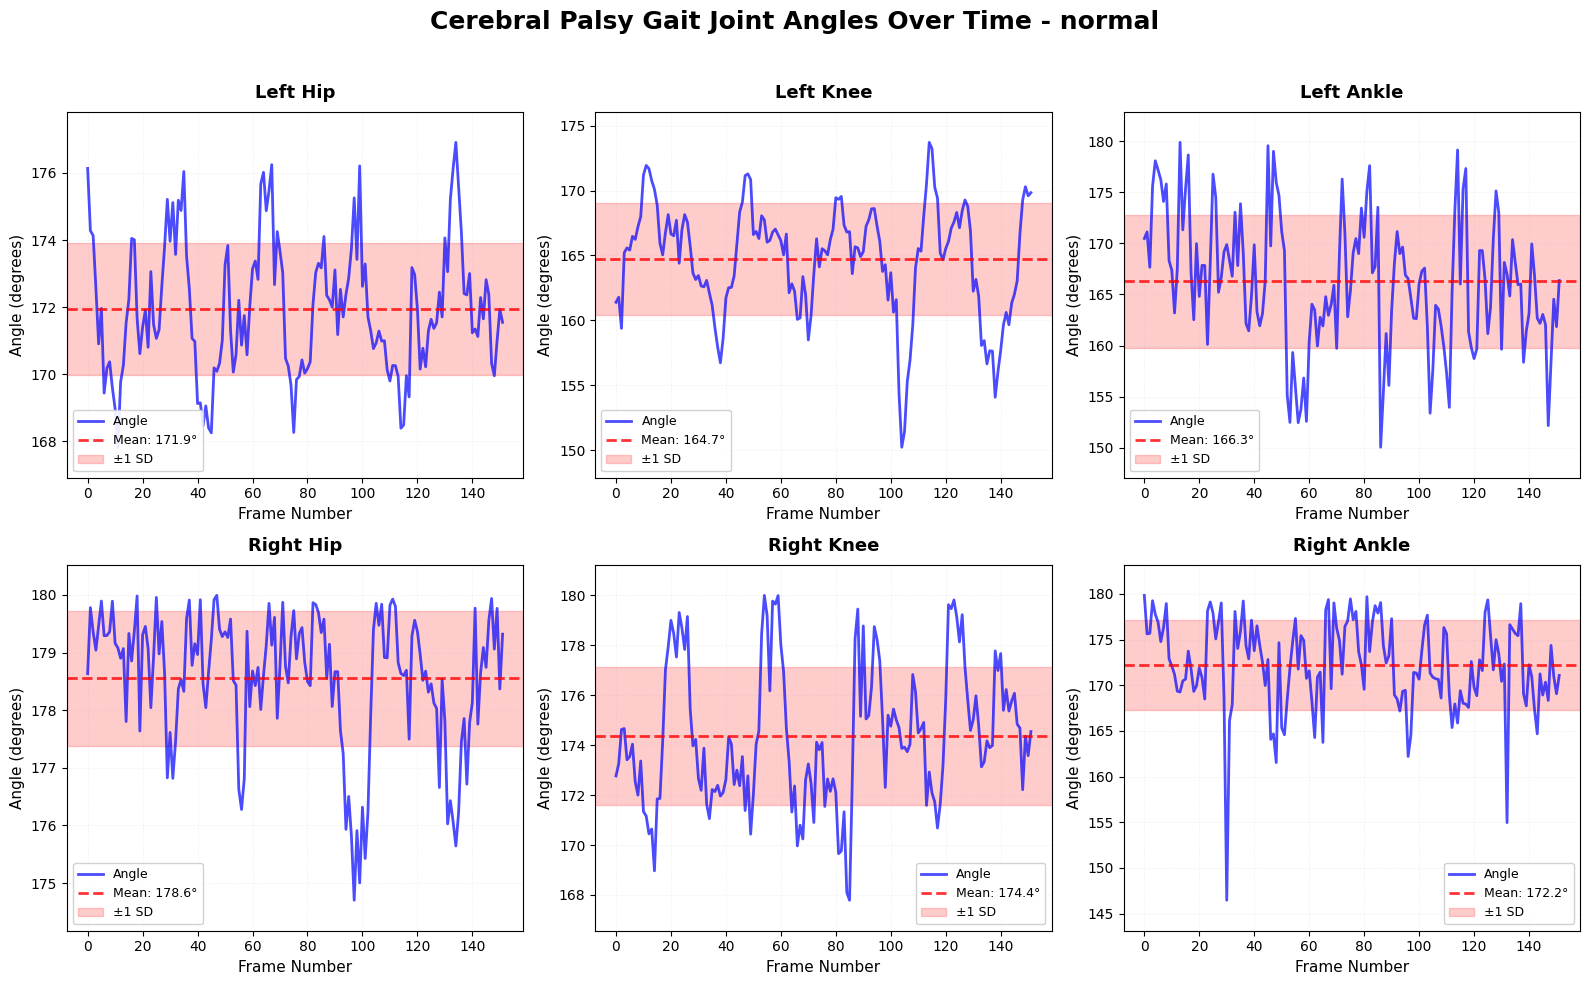


Joint Angle Statistics
Joint               Mean      Std      Min      Max    Range
----------------------------------------------------------------------
left_hip           171.9°     2.0°   167.8°   176.9°     9.1°
left_knee          164.7°     4.3°   150.2°   173.7°    23.5°
left_ankle         166.3°     6.5°   150.1°   179.9°    29.8°
right_hip          178.6°     1.2°   174.7°   180.0°     5.3°
right_knee         174.4°     2.8°   167.8°   180.0°    12.2°
right_ankle        172.2°     4.9°   146.5°   179.8°    33.4°



In [42]:
plot_joint_angles_statistics("Cerebral Palsy Gait", cerebralpalsy_joint_angles)

## 5. Extract Features for Classification

In [44]:
from ambient.classification.features import GaitFeatureVector

In [45]:
# Create feature vector
feature_vector = GaitFeatureVector.from_joint_angles(
    normal_joint_angles,
    sample_id=normal_sid,
    condition_label="normal"
)

print("Feature Vector:")
print(f"  Sample ID: {feature_vector.sample_id}")
print(f"  Condition: {feature_vector.condition_label}")
print(f"\nFeatures:")
for name in GaitFeatureVector.get_feature_names():
    value = getattr(feature_vector, name)
    print(f"  {name:20s}: {value:7.2f}")

Feature Vector:
  Sample ID: cljo32213001u3n6lel97up5f
  Condition: normal

Features:
  left_hip_mean       :  173.22
  left_knee_mean      :  167.69
  left_ankle_mean     :  146.31
  right_hip_mean      :  171.66
  right_knee_mean     :  167.68
  right_ankle_mean    :  149.59
  hip_asymmetry       :    1.56
  knee_asymmetry      :    0.01
  ankle_asymmetry     :    3.29
  left_hip_range      :   18.00
  left_knee_range     :   51.65
  left_ankle_range    :   45.18
  right_hip_range     :   19.91
  right_knee_range    :   37.77
  right_ankle_range   :   45.18


In [46]:
def extract_all_features(condition_paths, video_base_path):
    """Extract features from all condition directories."""
    all_features = []
    condition_counts = defaultdict(int)
    gavd_loader = GAVDDataLoader()
    
    for condition_path in condition_paths:
        condition_name = condition_path.name
        print(f"\nProcessing: {condition_name}")
        
        for csv_path in condition_path.glob("*.csv"):
            try:
                df = gavd_loader.load_gavd_data(str(csv_path))
                sequences = gavd_loader.organize_by_sequence(df)
                
                for seq_id in sequences:
                    try:
                        sequence_df = sequences[seq_id]
                        
                        # Extract keypoints
                        extractor = SequenceKeypointExtractor()
                        keypoints_array = extractor.extract_from_sequence(
                            sequence_df,
                            video_base_path=video_base_path,
                            verbose=False
                        )
                        
                        if not keypoints_array:
                            continue
                        
                        # Calculate joint angles
                        joint_angles = get_joint_angles(
                            keypoints_array=keypoints_array,
                            keypoint_format="BLAZEPOSE_33",
                            fps=30.0,
                            confidence_threshold=0.3,
                            sequence_id=seq_id
                        )
                        
                        if len(joint_angles.frames) == 0:
                            continue
                        
                        # Create feature vector
                        feature_vector = GaitFeatureVector.from_joint_angles(
                            joint_angles,
                            sample_id=seq_id,
                            condition_label=condition_name
                        )
                        
                        all_features.append(feature_vector)
                        condition_counts[condition_name] += 1
                        print(f"  ✓ {seq_id}")
                    
                    except Exception as e:
                        print(f"  ✗ {seq_id}: {e}")
            
            except Exception as e:
                print(f"  Error processing {csv_path.name}: {e}")
    
    return all_features, dict(condition_counts)

In [ ]:
# %%time

# Feature extraction is only needed if it has not been done already
# Check if you have extracted_features.pkl in the same directory
# # Extract all features
# all_features, condition_counts = extract_all_features(condition_paths, video_base_path)

# print(f"\n{'='*60}")
# print(f"Total features extracted: {len(all_features)}")
# print(f"\nCondition distribution:")
# for condition, count in sorted(condition_counts.items()):
#     print(f"  {condition:15s}: {count:3d} samples")


Processing: stroke


2026-01-23 21:22:14.791 | INFO     | ambient.utils.youtube_cache:download_youtube_urls:310 - Downloading: https://www.youtube.com/watch?v=8mTHlAIdea0


  ✓ cljvvsucg00043n6l4evgn7q4
[youtube] Extracting URL: https://www.youtube.com/watch?v=8mTHlAIdea0
[youtube] 8mTHlAIdea0: Downloading webpage
[youtube] 8mTHlAIdea0: Downloading android player API JSON


[info] 8mTHlAIdea0: Downloading 1 format(s): 18
[download] Destination: /Users/alexmui/dev/alexpose/data/youtube/8mTHlAIdea0.mp4
[download] 100% of    5.72MiB in 00:00:01 at 5.31MiB/s   
[Metadata] Adding metadata to "/Users/alexmui/dev/alexpose/data/youtube/8mTHlAIdea0.mp4"


I0000 00:00:1769232137.736007 7454838 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1769232137.790234 7454841 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769232137.800842 7454841 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
2026-01-23 21:22:18.115 | WARNING  | ambient.pose.keypoint_extractor:_process_frame:506 - Keypoint extraction returned 0 keypoints for frame 1739
2026-01-23 21:23:35.169 | INFO     | ambient.utils.youtube_cache:download_youtube_urls:310 - Downloading: https://www.youtube.com/watch?v=5gpoegYv1hs


...

  ✓ cljas04fw00f33n6lm5cvx9g6


2026-01-23 23:51:22.005 | WARNING  | ambient.pose.keypoint_extractor:_process_frame:506 - Keypoint extraction returned 0 keypoints for frame 952


  ✓ cljas2sou00ff3n6lasppj8h2


I0000 00:00:1769241174.612545 8165739 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1769241174.664611 8165741 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769241174.674532 8165744 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1769241383.457126 8187998 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1769241383.515447 8187999 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769241383.526255 8187999 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


  ✓ cljarcy3g00co3n6lzsn1x034

Total features extracted: 68

Condition distribution:
  cerebralpalsy  :  15 samples
  myopathic      :  20 samples
  normal         :  12 samples
  parkinsons     :   9 samples
  stroke         :  12 samples
CPU times: user 8min 26s, sys: 4min 43s, total: 13min 9s
Wall time: 2h 35min 59s


### Save and Load Feature Data

Let's create functions to save and load the extracted features to avoid re-extracting them every time.

In [ ]:
from ambient.utils.features import save_features, load_features

# save_path = save_features(all_features, condition_counts)

# print(f"\nFeatures saved to: {save_path}")

✓ Features saved successfully to: /Users/alexmui/dev/alexpose/experiments/exp5/extracted_features.pkl
  Total features: 68
  Conditions: ['stroke', 'myopathic', 'parkinsons', 'normal', 'cerebralpalsy']
  File size: 14.22 KB

Features saved to: /Users/alexmui/dev/alexpose/experiments/exp5/extracted_features.pkl


### Load Previously Extracted Features

To load previously saved features instead of re-extracting them, uncomment and run the cell below:

In [49]:
all_features, condition_counts = load_features()
print(f"\n{'='*60}")
print(f"Total features loaded: {len(all_features)}")
print(f"\nCondition distribution:")
for condition, count in sorted(condition_counts.items()):
     print(f"  {condition:15s}: {count:3d} samples")

✓ Features loaded successfully from: /Users/alexmui/dev/alexpose/experiments/exp5/extracted_features.pkl
  Saved on: 2026-01-24T00:29:12.626096
  Total features: 68
  Conditions: ['stroke', 'myopathic', 'parkinsons', 'normal', 'cerebralpalsy']

Total features loaded: 68

Condition distribution:
  cerebralpalsy  :  15 samples
  myopathic      :  20 samples
  normal         :  12 samples
  parkinsons     :   9 samples
  stroke         :  12 samples
